In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
print("Libraries imported successfully!")

Libraries imported successfully!


In [7]:
df = pd.read_csv('Sample - Superstore.csv', encoding='latin-1')
print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (9994, 21)


In [8]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [9]:
print("Dataset Info:")
print(df.info())
print("\nBasic Statistics:")
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [10]:
print("Missing Values:")
print(df.isnull().sum())
print("\nNo missing values means our data is clean and ready for analysis!")

Missing Values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

No missing values means our data is clean and ready for analysis!


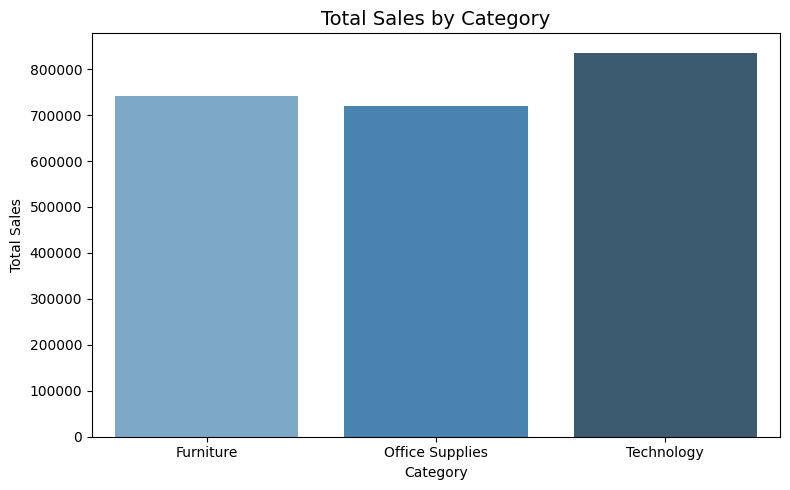

          Category        Sales
0        Furniture  741999.7953
1  Office Supplies  719047.0320
2       Technology  836154.0330


In [11]:
plt.figure(figsize=(8,5))
category_sales = df.groupby('Category')['Sales'].sum().reset_index()
sns.barplot(x='Category', y='Sales', data=category_sales, palette='Blues_d')
plt.title('Total Sales by Category', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()
print(category_sales)

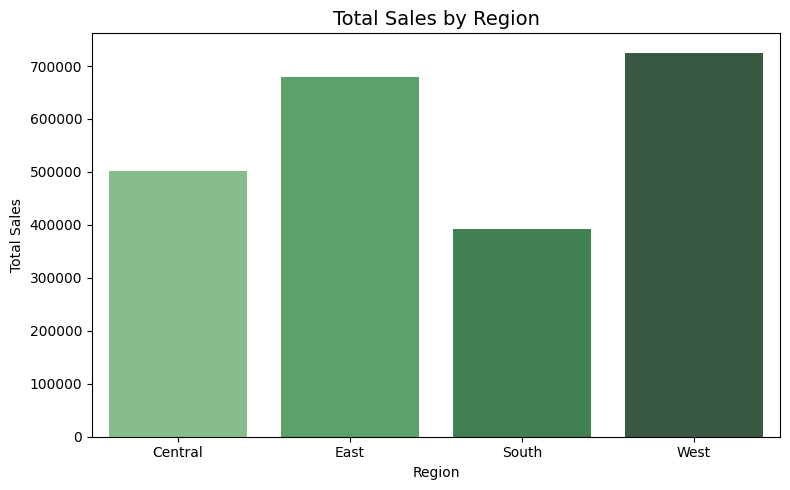

    Region        Sales
0  Central  501239.8908
1     East  678781.2400
2    South  391721.9050
3     West  725457.8245


In [12]:
plt.figure(figsize=(8,5))
region_sales = df.groupby('Region')['Sales'].sum().reset_index()
sns.barplot(x='Region', y='Sales', data=region_sales, palette='Greens_d')
plt.title('Total Sales by Region', fontsize=14)
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()
print(region_sales)

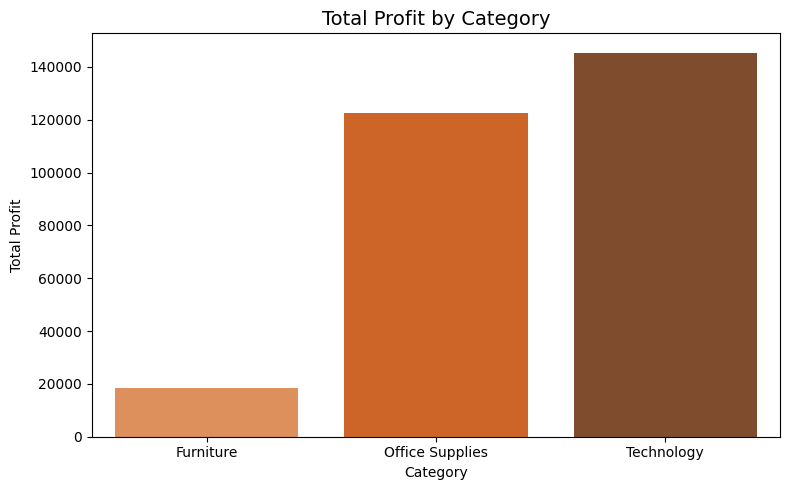

          Category       Profit
0        Furniture   18451.2728
1  Office Supplies  122490.8008
2       Technology  145454.9481


In [13]:
plt.figure(figsize=(8,5))
category_profit = df.groupby('Category')['Profit'].sum().reset_index()
sns.barplot(x='Category', y='Profit', data=category_profit, palette='Oranges_d')
plt.title('Total Profit by Category', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Total Profit')
plt.tight_layout()
plt.show()
print(category_profit)

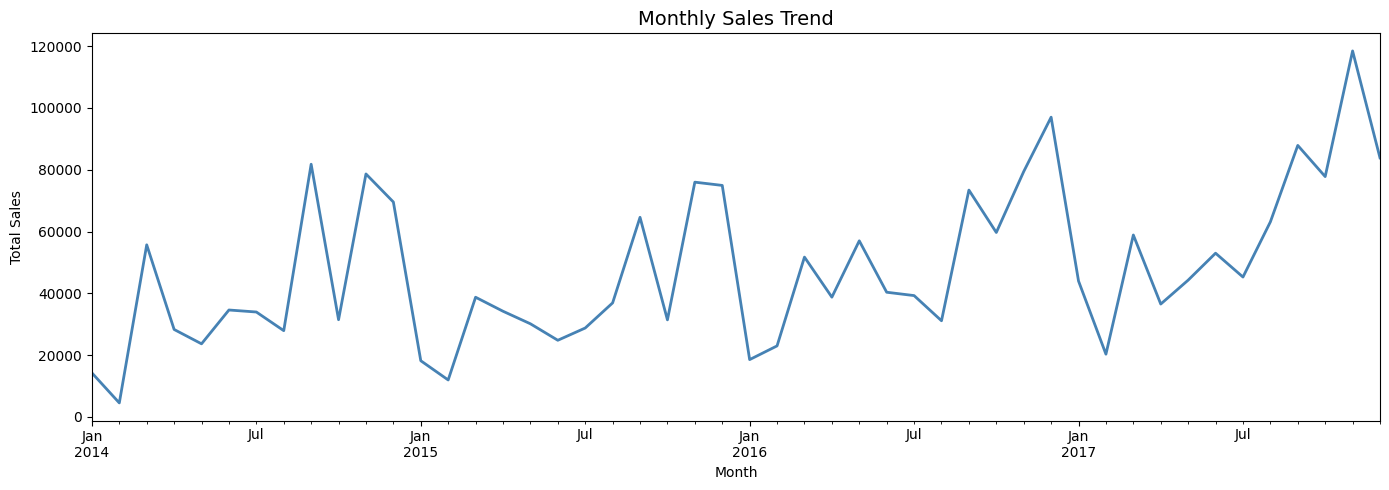

In [14]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month'] = df['Order Date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Sales'].sum()
plt.figure(figsize=(14,5))
monthly_sales.plot(kind='line', color='steelblue', linewidth=2)
plt.title('Monthly Sales Trend', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

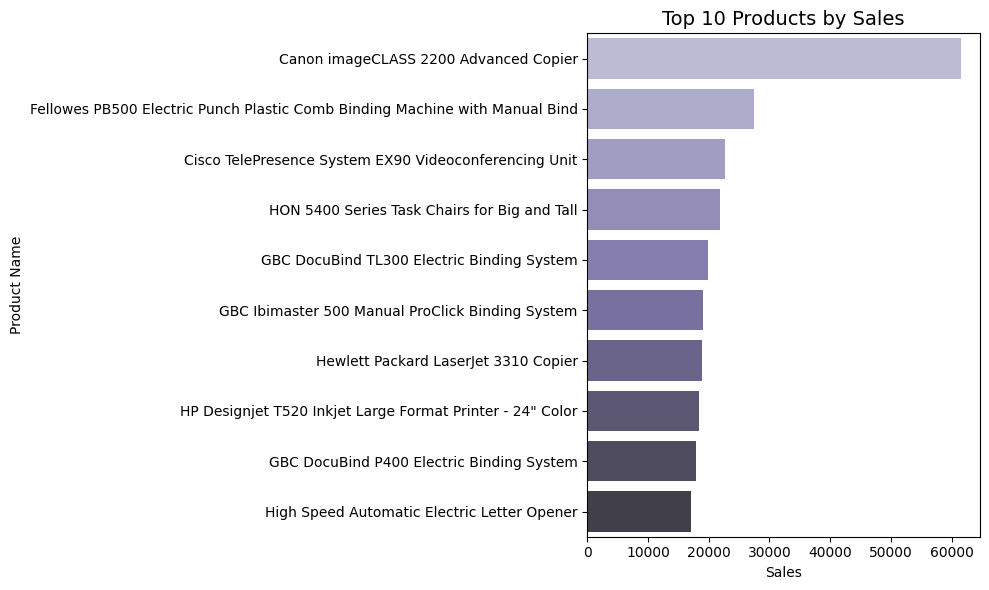

In [15]:
top_products = df.groupby('Product Name')['Sales'].sum().reset_index()
top_products = top_products.sort_values('Sales', ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x='Sales', y='Product Name', data=top_products, palette='Purples_d')
plt.title('Top 10 Products by Sales', fontsize=14)
plt.tight_layout()
plt.show()

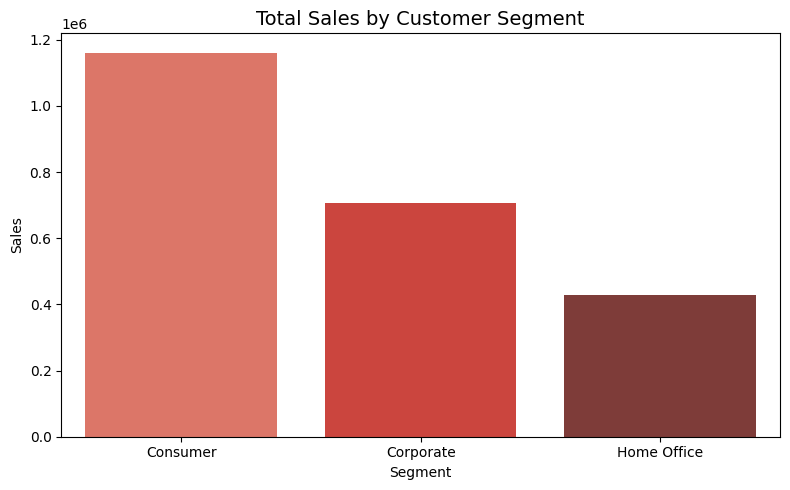

       Segment         Sales
0     Consumer  1.161401e+06
1    Corporate  7.061464e+05
2  Home Office  4.296531e+05


In [16]:
plt.figure(figsize=(8,5))
segment_sales = df.groupby('Segment')['Sales'].sum().reset_index()
sns.barplot(x='Segment', y='Sales', data=segment_sales, palette='Reds_d')
plt.title('Total Sales by Customer Segment', fontsize=14)
plt.tight_layout()
plt.show()
print(segment_sales)

In [17]:
print("=" * 50)
print("KEY INSIGHTS FROM SUPERSTORE EDA")
print("=" * 50)
print(f"Total Revenue: ${df['Sales'].sum():,.2f}")
print(f"Total Profit: ${df['Profit'].sum():,.2f}")
print(f"Total Orders: {df['Order ID'].nunique()}")
print(f"Profit Margin: {(df['Profit'].sum()/df['Sales'].sum()*100):.2f}%")
print(f"Top Category: {category_sales.loc[category_sales['Sales'].idxmax(), 'Category']}")
print(f"Top Region: {region_sales.loc[region_sales['Sales'].idxmax(), 'Region']}")
print("=" * 50)

KEY INSIGHTS FROM SUPERSTORE EDA
Total Revenue: $2,297,200.86
Total Profit: $286,397.02
Total Orders: 5009
Profit Margin: 12.47%
Top Category: Technology
Top Region: West


In [ ]:
from google.colab import drive
drive.mount('/content/drive')